In [1]:
# %matplotlib widget   # I don't need or want to zoom and pan plots. 

# Perturbed TOA OLR expressed as TB change
####Brian Mapes, March 8 2025 

I want to see how TOA radiation is changed by adiabatic vertical displacements by internal waves. To compute this, the local gradient of vertical profiles of conserved variables $\theta$ and q is multiplied by a finite increment (+1 or +10mb) at each level in the numerical profile, and that increment is added. Note that this reassignment of a value from a higher p is an *upward* motion. Of course $\theta$ must be rescaled to T units for the RT calculation. 

p is the natural coordinate for RT, since it is mass or strictly the number of molecules (times cross-section per molecule) that matters. Gas is sparse so it doesn't matter what spatial layer it is distributed over. However the depth of the layers over which the increments are applied is not uniform, the p array is not evenly spaced. As long as everything is linear, that can be corrected by rescaling the "sensitivity kernels" to adiabatic-q and adiabatic-T changes, normalizing them to a common perturbed-layer depth. A linearity test is the important compuation here, so we tried 1mb and 10mb upward displacements (reasonable amplitudes for ambient internal waves, the latter is used as whiskers in my mseplots-pkg balloon sounding display code for example.  

These plots are TB of irradiance (a hemispheric integral), a little different from radiance (what a satellite sees, which is a bit different at nadir vs. closer to the limb). See my edits to pyarts-lectures notebook (BEM-03-RTcalc) for a radiance computation at nadir. So, slight angle or "limb corrections" could be brought in but that is a very secondary matter.


### Original notebook: 06-olr:
#### arts-lectures Exercise No. 6 -- Outgoing Longwave Radiation (OLR)

Run ARTS on the Jupyter notebook olr.ipynb . This will calculate the spectrum
of outgoing longwave radiation for a midlatitude-summer atmosphere.
Our calculation trades accuracy for computational efficiency. For
example, we use only water vapor and carbon dioxide as absorbers.
We use only 300 frequency grid points and approximately 54,000 spectral
lines, whereas for accurate calculations one needs at least 10,000
frequency grid points and 500,000 spectral lines, taking into account
absorbing species like ozone and methane. The script plots the spectral
irradiance, in SI units, as a function of wavenumber. Planck curves
for different temperatures are shown for comparison. We integrate
the whole spectrum to quantify the power per square that is emitted
by the atmosphere (value in title).

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
from pyarts import xml
from pyarts.arts import convert
from olr_module import calc_olr_from_atmfield, Change_T_with_RH_const, cmap2rgba, planck

os.makedirs("plots", exist_ok=True)

In [3]:
# Read input atmosphere
atmfield = xml.load("input/midlatitude-summer.xml")
atmfield = xml.load("input/tropical.xml")

# Scale the CO2 concentration
atmfield.scale("abs_species-CO2", 1)

# Add a constant value to the temperature
atmfield.set("T", atmfield.get("T") + 0)

# Add a constant value to the temperature but 
# without changing relative humidity 
atmfield = Change_T_with_RH_const(atmfield,DeltaT=0)

# Calculate the outgoing-longwave radiation
f, olr = calc_olr_from_atmfield(atmfield, verbosity=0)
fall = f 

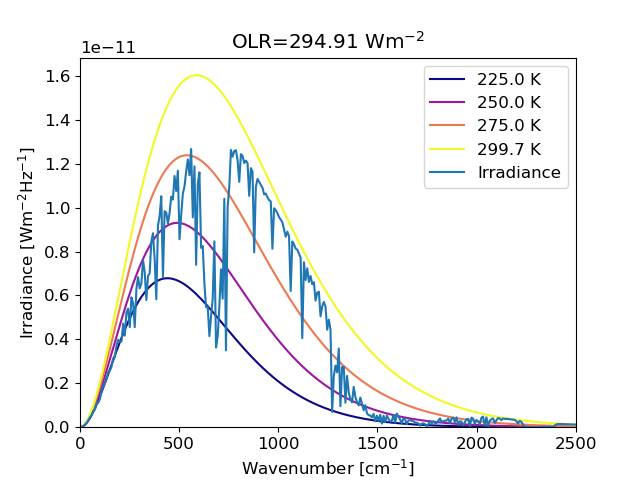

In [4]:
# Plotting.
import matplotlib
font = {'size'   : 12}
matplotlib.rc('font', **font)

wn = convert.freq2kaycm(f)

temps = [225, 250, 275, atmfield.get("T", keep_dims=False)[0]]
temp_colors = cmap2rgba("plasma", len(temps))

fig, ax = plt.subplots()
for t, color in sorted(zip(temps, temp_colors)):
    ax.plot(
        wn, np.pi * planck(f, t), label=f"{t:3.1f} K", color=color
    )
ax.plot(wn, olr, color="C0", label="Irradiance")
ax.legend()
ax.set_title(rf"OLR={np.trapezoid(olr, f):3.2f} $\sf Wm^{{-2}}$")
ax.set_xlim(wn.min(), wn.max())
ax.set_xlabel(r"Wavenumber [$\sf cm^{-1}$]")
ax.set_ylabel(r"Irradiance [$\sf Wm^{-2}Hz^{-1}$]")
ax.set_ylim(bottom=0)
fig.savefig("plots/tropicalolr.pdf")

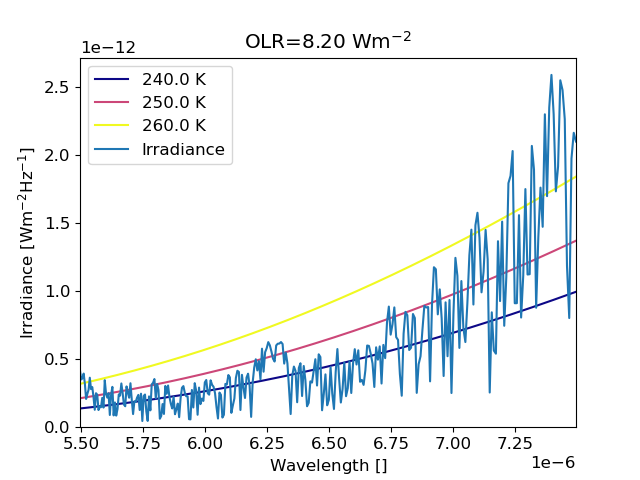

In [5]:
# Plotting for my frequency range: WV channels 
#f8, BT8_6_2, od = run_arts(species, zenith_angle, height, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6)
#f9, BT9_6_9, od = run_arts(species, zenith_angle, height, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.7e-6)
#f10,BT10_7_3,od = run_arts(species, zenith_angle, height, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.2e-6)

f, olr = calc_olr_from_atmfield(atmfield, verbosity=3, fmin=3e8/ 7.5e-6, fmax=3e8/ 5.5e-6) # 5-8 microns 

wn = convert.freq2kaycm(f)
wl = convert.freq2wavelen(f)

temps = [240, 250, 260] # surface T , atmfield.get("T", keep_dims=False)[0]]
temp_colors = cmap2rgba("plasma", len(temps))

fig, ax = plt.subplots()
for t, color in sorted(zip(temps, temp_colors)):
    ax.plot(
        wl, np.pi * planck(f, t), label=f"{t:3.1f} K", color=color
    )
ax.plot(wl, olr, color="C0", label="Irradiance")
ax.legend()
ax.set_title(rf"OLR={np.trapezoid(olr, f):3.2f} $\sf Wm^{{-2}}$")
ax.set_xlim(wl.min(), wl.max())
ax.set_xlabel(r"Wavelength [$\sf $]")
ax.set_ylabel(r"Irradiance [$\sf Wm^{-2}Hz^{-1}$]")
ax.set_ylim(bottom=0)
fig.savefig("plots/tropicalWVolr.pdf")

In [6]:
# Channel TB from OLR integral over that band 
def TB_from_olr(f,olr):
    temps = np.arange(200,320,1)  # a range of plausible temperatures (K) to interpolate linearly among
    FBs = []                      # Blackbody fluxes corresponding to above 
    for t in temps:
        FBs.append( np.trapezoid(np.pi * planck(f, t), f) )

    myF = np.trapezoid(olr, f)
    TB_interp = np.interp(myF, FBs, temps)
    
    return TB_interp

In [8]:
# Expressing WV channel fluxes AS TB, compare to MY_rtcalc results for midlat summer

# Copy wavelengths from MYrtcalc notebook where I worked it all out
#f8, BT8_6_2, od = run_arts(species, zenith_angle, height, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6)
#f9, BT9_6_9, od = run_arts(species, zenith_angle, height, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.7e-6)
#f10,BT10_7_3,od = run_arts(species, zenith_angle, height, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.2e-6)

atmfield = xml.load("input/midlatitude-summer.xml")

f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 

In [9]:
# Compare to midlat summer from MY_rtcalc 241.6654609921063 248.8933227778732 260.0744514335408
T8 = TB_from_olr(f8, olr8)
T9 = TB_from_olr(f9, olr9)
T10= TB_from_olr(f10,olr10)

T8,T9,T10

(np.float64(237.8640938703809),
 np.float64(245.63263597674032),
 np.float64(256.71398373465104))

-------------------
# Ready to perturb! 
from olr_module.py: 

    vmr = atmfield.get("abs_species-H2O")
    T = atmfield.get("T")
    p = atmfield.grids[1][:].reshape(T.shape)

That shape is (1, 46, 1, 1)

    # update atmosphere field
    atmfield.set("T", T + DeltaT)
    atmfield.set("abs_species-H2O", vmr)
    

In [10]:
q = atmfield.get("abs_species-H2O")
T = atmfield.get("T")
p = atmfield.grids[1][:].reshape(T.shape)

plt.scatter( np.squeeze(T), -np.squeeze(p) );

In [11]:
# Construct a potential temperature and its derivative 
# d(th)/dp <0, yes checked

th= T * ((100000./(p))**(287./1004))
dthdp = np.gradient(np.squeeze(th))/np.gradient(np.squeeze(p))

plt.scatter( dthdp*100, -np.squeeze(p) )
plt.xlim([-1,0])
plt.title('d(th)/dp in K per millibar');

In [12]:
dqdp = np.gradient(np.squeeze(q))/np.gradient(np.squeeze(p))

plt.scatter( dqdp*100*1000, -np.squeeze(p) )
plt.title('d(q)/dp in g/kg per millibar');

In [13]:
# Consider TB change due to local perturbations to T and q, each scaled to vertical displacements of 1mb

# Container for results 
DT8s_th = []
DT8s_q  = []
DT8s_bo = [] 
DT9s_th = []
DT9s_q  = []
DT9s_bo = [] 
DT10s_th = []
DT10s_q  = []
DT10s_bo = [] 


for ilev in np.arange(1,23): 
    print(ilev) 
    atmfield = xml.load("input/midlatitude-summer.xml")  # RESET TO ORIGINAL PROFILE
    q = atmfield.get("abs_species-H2O")
    T = atmfield.get("T")
    p = atmfield.grids[1][:].reshape(T.shape)

    dq =  dqdp[ilev] * 100. # a 1mb vertial displacement locally in this layer 
    dth= dthdp[ilev] * 100.  
    dT = dth * T[0,ilev,0,0]/th[0,ilev,0,0]  # convert to T units 

# T pert alone first; can add to T since it will be overwritten next time thru loop 
    T[0,ilev,0,0] += dT
    atmfield.set("T", T)
    
    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_th.append(T8p - T8)
    DT9s_th.append(T9p - T9)
    DT10s_th.append(T10p - T10)

# Next, Both T and q perts 
    q[0,ilev,0,0] += dq
    atmfield.set("abs_species-H2O", q)

    atmfield.set("abs_species-H2O", q+dq)
    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_bo.append(T8p - T8)
    DT9s_bo.append(T9p - T9)
    DT10s_bo.append(T10p - T10)

# Finally, q pert alone, subtracting T pert which had been added above   
    T[0,ilev,0,0] -= dT
    atmfield.set("T", T)

    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_q.append(T8p - T8)
    DT9s_q.append(T9p - T9)
    DT10s_q.append(T10p - T10)
    

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22


In [14]:
paxis = p[0,1:23,0,0]/100
paxis

array([1013. ,  902. ,  802. ,  710. ,  628. ,  554. ,  487. ,  426. ,
        372. ,  324. ,  281. ,  243. ,  209. ,  179. ,  153. ,  130. ,
        111. ,   95. ,   81.2,   69.5,   59.5,   51. ])

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

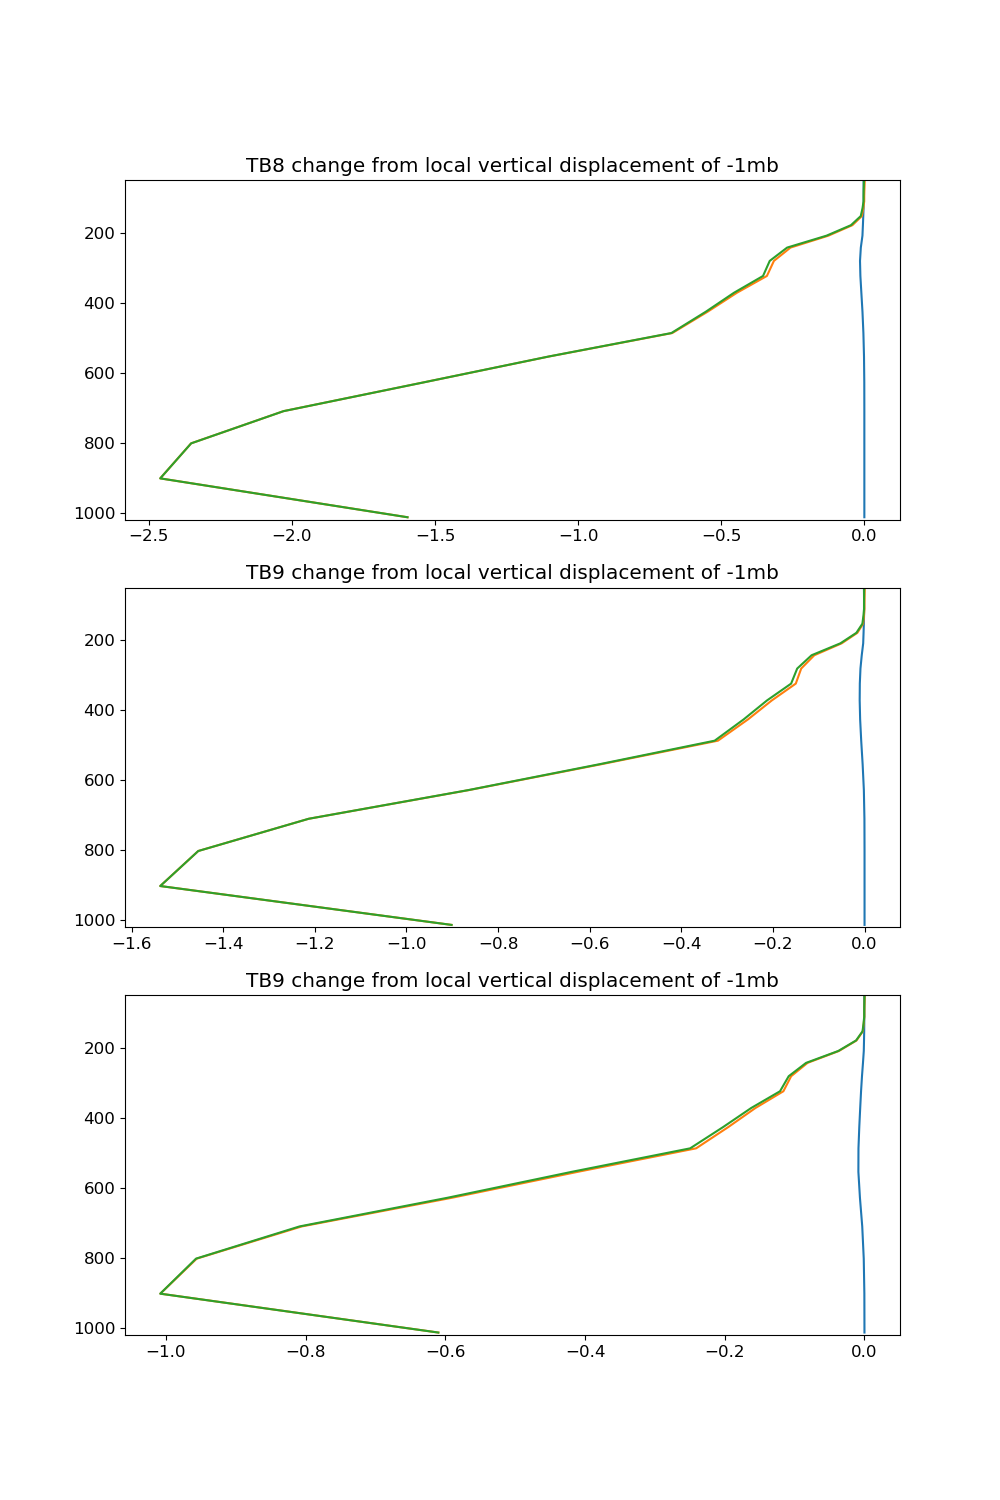

In [26]:
plt.figure(figsize=(10,15))

plt.subplot(311)
plt.plot(DT8s_th, paxis)
plt.plot(DT8s_q, paxis)
plt.plot(DT8s_bo, paxis)
plt.ylim([1020,50]);
plt.title('TB8 change from local vertical displacement of -1mb')

plt.subplot(312)
plt.plot(DT9s_th, paxis)
plt.plot(DT9s_q, paxis)
plt.plot(DT9s_bo, paxis)
plt.ylim([1020,50]);
plt.title('TB9 change from local vertical displacement of -1mb')

plt.subplot(313)
plt.plot(DT10s_th, paxis)
plt.plot(DT10s_q, paxis)
plt.plot(DT10s_bo, paxis)
plt.ylim([1020,50]);
plt.title('TB9 change from local vertical displacement of -1mb')

plt.close

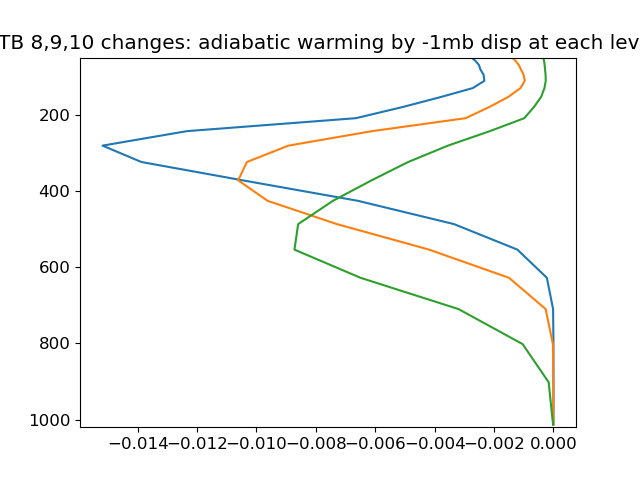

In [31]:
plt.figure()
plt.plot(DT8s_th, paxis)
plt.plot(DT9s_th, paxis)
plt.plot(DT10s_th, paxis);
plt.ylim([1020,50]);
plt.title('TB 8,9,10 changes: adiabatic warming by -1mb disp at each level');

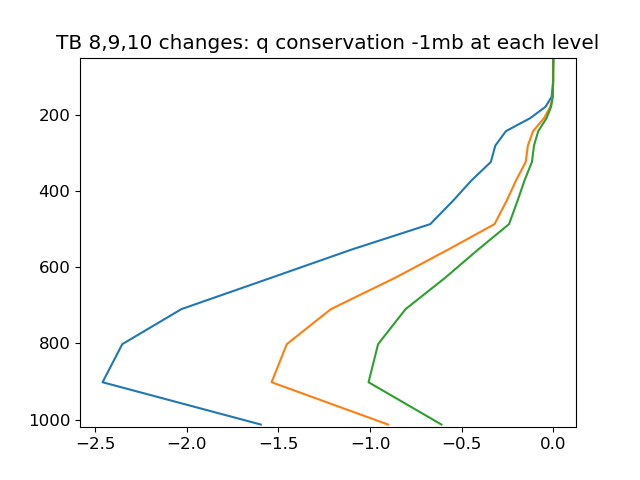

In [32]:
plt.figure()
plt.plot(DT8s_q, paxis)
plt.plot(DT9s_q, paxis)
plt.plot(DT10s_q, paxis);
plt.ylim([1020,50]);
plt.title('TB 8,9,10 changes: q conservation -1mb at each level');

# Use 10mb displacement instead of 1mb to test linearity 

In [37]:
# Do it for 10mb to see how linear it is 
# Consider TB change due to local perturbations to T and q, each scaled to vertical displacements of 1mb

# Container for results 
DT8s_th10 = []
DT8s_q10  = []
DT8s_bo10 = [] 
DT9s_th10 = []
DT9s_q10  = []
DT9s_bo10 = [] 
DT10s_th10 = []
DT10s_q10  = []
DT10s_bo10 = [] 


for ilev in np.arange(1,23): 
    print(ilev) 
    atmfield = xml.load("input/midlatitude-summer.xml")  # RESET TO ORIGINAL PROFILE
    q = atmfield.get("abs_species-H2O")
    T = atmfield.get("T")
    p = atmfield.grids[1][:].reshape(T.shape)

    dq =  dqdp[ilev] * 1000. # a 10mb vertial displacement locally in this layer 
    dth= dthdp[ilev] * 1000.  
    dT = dth * T[0,ilev,0,0]/th[0,ilev,0,0]  # convert to T units 

# T pert alone first; can add to T since it will be overwritten next time thru loop 
    T[0,ilev,0,0] += dT
    atmfield.set("T", T)
    
    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_th10.append(T8p - T8)
    DT9s_th10.append(T9p - T9)
    DT10s_th10.append(T10p - T10)

# Next, Both T and q perts 
    q[0,ilev,0,0] += dq
    atmfield.set("abs_species-H2O", q)

    atmfield.set("abs_species-H2O", q+dq)
    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_bo10.append(T8p - T8)
    DT9s_bo10.append(T9p - T9)
    DT10s_bo10.append(T10p - T10)

# Finally, q pert alone, subtracting T pert which had been added above   
    T[0,ilev,0,0] -= dT
    atmfield.set("T", T)

    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_q10.append(T8p - T8)
    DT9s_q10.append(T9p - T9)
    DT10s_q10.append(T10p - T10)
    

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22


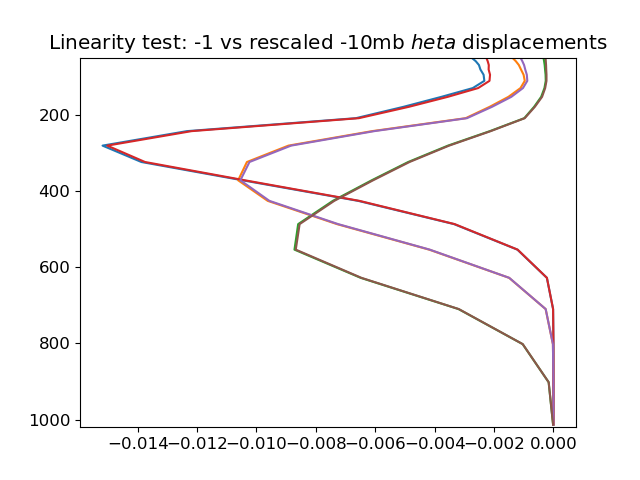

In [38]:
plt.figure()
plt.plot(DT8s_th, paxis)
plt.plot(DT9s_th, paxis)
plt.plot(DT10s_th, paxis);
plt.plot(np.array(DT8s_th10)/10, paxis)
plt.plot(np.array(DT9s_th10)/10, paxis)
plt.plot(np.array(DT10s_th10)/10, paxis);

plt.ylim([1020,50]);
plt.title('Linearity test: -1 vs rescaled -10mb $\theta$ displacements');

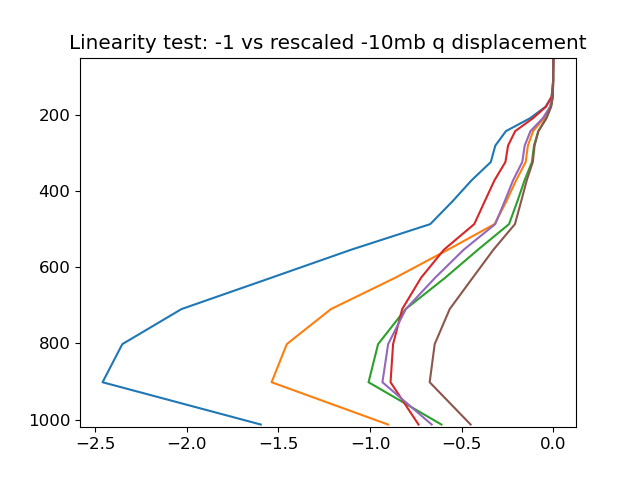

In [39]:
plt.figure()
plt.plot(DT8s_q, paxis)
plt.plot(DT9s_q, paxis)
plt.plot(DT10s_q, paxis);
plt.plot(np.array(DT8s_q10)/10, paxis)
plt.plot(np.array(DT9s_q10)/10, paxis)
plt.plot(np.array(DT10s_q10)/10, paxis);

plt.ylim([1020,50]);
plt.title('Linearity test: -1 vs rescaled -10mb q displacement');  

# RESULT: very nonlinear! Or nonlocal, more to the point, since upper perturbations screen lower perturbations.  

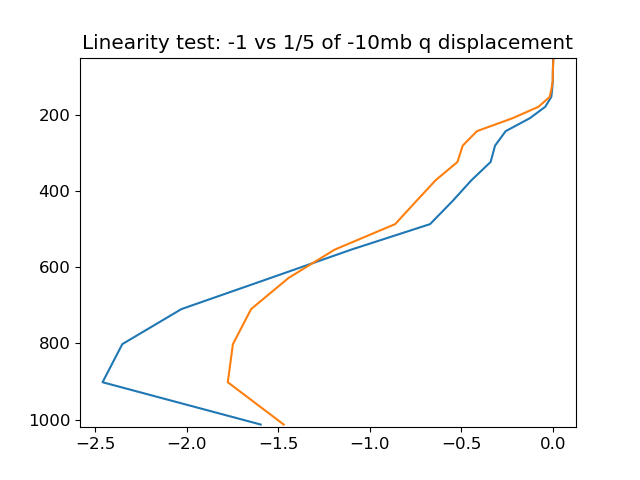

In [46]:
# Focus on channel 8 
plt.figure()
plt.plot(DT8s_q, paxis)
#plt.plot(DT9s_q, paxis)
#plt.plot(DT10s_q, paxis);
plt.plot(np.array(DT8s_q10)/5, paxis)
#plt.plot(np.array(DT9s_q10)/10, paxis)
#plt.plot(np.array(DT10s_q10)/10, paxis);

plt.ylim([1020,50]);
plt.title('Linearity test: -1 vs 1/5 of -10mb q displacement');  


In [42]:
np.log(10)

np.float64(2.302585092994046)